In [69]:
import sqlalchemy as db
import matplotlib.pyplot as plt
import csv

In [31]:
all_data = []
with open('train_data.csv', encoding='utf-8') as file:
    train_data = csv.reader(file)
    header = next(train_data)
    for row in train_data:
        row_dict = {header[i]: row[i] for i in range(len(header))}
        all_data.append(row_dict)

In [32]:
engine = db.create_engine('sqlite:///mydb3.db')

In [33]:
conn = engine.connect()

In [34]:
result = conn.execute(db.text("SELECT Sex, AVG(Survived) * 100 AS survival_rate FROM train_data GROUP BY Sex"))

print("Процент выживших по полу:")
for row in result:
  if row.Sex == 1:
    sex = "мужчина"
  else:
    sex = "женщина"
  rate = row.survival_rate
  print(f"{sex}: {rate:.1f}%")

Процент выживших по полу:
женщина: 74.9%
мужчина: 18.9%


In [66]:
p1 = conn.execute(db.text("SELECT AVG(Survived) * 100 FROM train_data WHERE Pclass_1 = 1")).scalar()
p2 = conn.execute(db.text("SELECT AVG(Survived) * 100 FROM train_data WHERE Pclass_2 = 1")).scalar()
p3 = conn.execute(db.text("SELECT AVG(Survived) * 100 FROM train_data WHERE Pclass_3 = 1")).scalar()

print("Процент выживших по классу:")
print(f"Первый класс: {p1:.1f}%")
print(f"Второй класс: {p2:.1f}%")
print(f"Третий класс: {p3:.1f}%")

Процент выживших по классу:
Первый класс: 61.7%
Второй класс: 48.5%
Третий класс: 24.7%


In [64]:
print("Процент выживших по полу и классу:")

classes = [1, 2, 3]
sexes = {0: "женщин", 1: "мужчин"}

for p_class in classes:
    print(f"\n{p_class} класс:")
    for sex_id, sex_name in sexes.items():
        pclass_col = f'Pclass_{p_class}'
        query = conn.execute(db.text(f"SELECT AVG(Survived) * 100 FROM train_data WHERE Sex = {sex_id} AND {pclass_col} = 1")).scalar()
        print(f"Выживаемость {sex_name}: {query:.1f}%")


Процент выживших по полу и классу:

1 класс:
Выживаемость женщин: 96.3%
Выживаемость мужчин: 36.6%

2 класс:
Выживаемость женщин: 92.9%
Выживаемость мужчин: 15.8%

3 класс:
Выживаемость женщин: 51.6%
Выживаемость мужчин: 13.4%


In [36]:
q1 = conn.execute(db.text("SELECT AVG(Survived) * 100 FROM train_data WHERE Emb_1 = 1")).scalar()
q2 = conn.execute(db.text("SELECT AVG(Survived) * 100 FROM train_data WHERE Emb_2 = 1")).scalar()
q3 = conn.execute(db.text("SELECT AVG(Survived) * 100 FROM train_data WHERE Emb_3 = 1")).scalar()

print("Процент выживших по порту на котором они зашли:")
print(f"Первый порт: {q1:.1f}%")
print(f"Второй порт: {q2:.1f}%")
print(f"Третий порт: {q3:.1f}%")

Процент выживших по порту на котором они зашли:
Первый порт: 54.4%
Второй порт: 39.7%
Третий порт: 34.3%


In [37]:
result = conn.execute(db.text("SELECT Family_size, AVG(Survived) * 100 AS rate, COUNT(*) AS total_passengers FROM train_data GROUP BY Family_size ORDER BY Family_size"))

print("Выживаемость по размеру семьи:")
for row in result:
    print(f"Размер семьи {(row.Family_size * 10):.0f}: {row.rate:.1f}% (всего {row.total_passengers})")


Выживаемость по размеру семьи:
Размер семьи 0: 31.2% (всего 475)
Размер семьи 1: 53.1% (всего 147)
Размер семьи 2: 56.7% (всего 90)
Размер семьи 3: 73.1% (всего 26)
Размер семьи 4: 20.0% (всего 15)
Размер семьи 5: 15.8% (всего 19)
Размер семьи 6: 40.0% (всего 10)
Размер семьи 7: 0.0% (всего 6)
Размер семьи 10: 0.0% (всего 4)


In [38]:
result = conn.execute(db.text("SELECT Fare, Survived FROM train_data"))

prices = []
status = []
for row in result:
    prices.append(row.Fare * 100)
    status.append(row.Survived)

for i in range(0, 101, 10):
    died = 0
    survived = 0
    for j in range(len(prices)):
        if i <= prices[j] < i + 10:
            if status[j] == 0:
                died += 1
            else:
                survived += 1
    total = died + survived
    if total > 0:
        rate = (survived / total) * 100
        print(f"{i}-{i+10}: погибло {died}, выжило {survived}, всего {total}, выживаемость {rate:.1f}%")

0-10: погибло 440, выжило 207, всего 647, выживаемость 32.0%
10-20: погибло 32, выжило 62, всего 94, выживаемость 66.0%
20-30: погибло 8, выжило 22, всего 30, выживаемость 73.3%
30-40: погибло 0, выжило 1, всего 1, выживаемость 100.0%
40-50: погибло 4, выжило 7, всего 11, выживаемость 63.6%
50-60: погибло 2, выжило 4, всего 6, выживаемость 66.7%
100-110: погибло 0, выжило 3, всего 3, выживаемость 100.0%


In [50]:
result = conn.execute(db.text("SELECT Age, Survived FROM train_data"))

age = []
status = []
for row in result:
    age.append(row.Age * 100)
    status.append(row.Survived)

for i in range(0, 101, 10):
    died = 0
    survived = 0
    for j in range(len(age)):
        if i <= age[j] < i + 10:
            if status[j] == 0:
                died += 1
            else:
                survived += 1
    total = died + survived
    if total > 0:
        rate = (survived / total) * 100
        print(f"{i}-{i+10}: погибло {died}, выжило {survived}, всего {total}, выживаемость {rate:.1f}%")

0-10: погибло 13, выжило 30, всего 43, выживаемость 69.8%
10-20: погибло 16, выжило 12, всего 28, выживаемость 42.9%
20-30: погибло 98, выжило 51, всего 149, выживаемость 34.2%
30-40: погибло 208, выжило 109, всего 317, выживаемость 34.4%
40-50: погибло 55, выжило 52, всего 107, выживаемость 48.6%
50-60: погибло 45, выжило 21, всего 66, выживаемость 31.8%
60-70: погибло 25, выжило 21, всего 46, выживаемость 45.7%
70-80: погибло 15, выжило 9, всего 24, выживаемость 37.5%
80-90: погибло 11, выжило 0, всего 11, выживаемость 0.0%
100-110: погибло 0, выжило 1, всего 1, выживаемость 100.0%


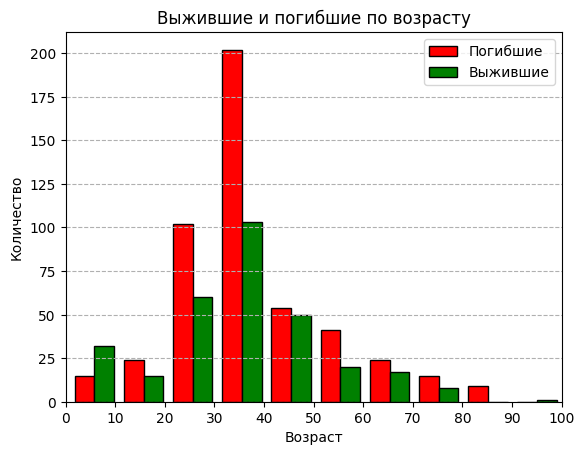

In [65]:
survived = []
died = []

for person in all_data:
    age = person.get('Age')
    survived_status = person.get('Survived')

    age = float(age) * 100
    survived_status = int(survived_status)

    if survived_status == 1:
        survived.append(age)
    else:
        died.append(age)

plt.hist([died, survived], bins=10, stacked=False, color=["red", "green"], edgecolor='black')
plt.title('Выжившие и погибшие по возрасту')
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.legend(['Погибшие', 'Выжившие'])
plt.xticks(range(0, 101, 10))
plt.xlim(0, 100)
plt.grid(axis='y', linestyle='--')
plt.show()